# Does the Aasiaat story replicate? — four stations

The Aasiaat notebooks found two headline results: detection agreement below
useful skill at every neighbourhood scale, and a ~3× satellite-high
accumulation bias at the 1 km AGL reference level. This notebook repeats both
analyses, with identical conventions, at the three stations added to the
network — **Nuuk** (98% gauge, year-round), **Tasiilaq** and
**Ittoqqortoormiit** (records start Mar 2025) — with Aasiaat alongside as the
reference. Four sites agreeing turns a station finding into a result.

Conventions inherited unchanged from `compare_earthcare_dmi_events` /
`_accumulation` (see those notebooks for the full method text and
references): profiles ≤ 100 km, `convergence_status == 0`, rates < 20 mm/h
screened, snowfall at 1000 m AGL; station snow-phase = precip in hours with
T ≤ +1.5 °C; matched window = hourly stamps overlapping overpass ± 30 min;
FSS with the satellite threshold harmonized to the gauge floor (0.1 mm/h);
accumulation via the Palerme two-stage estimator (zeros included, equal
overpass weight) with a bootstrap over overpasses.

**One station-specific mask:** Ittoqqortoormiit's gauge reported physically
impossible precipitation during its first two months (17 mm/h at −20 °C in
calm air; a 109 mm day) — a commissioning-grade instrument fault the generic
QC cannot catch. Its precipitation is **masked before 2025-05-01**
throughout. Monthly gauge totals anywhere are reported only when ≥ 80% of
the month's hours have data.

## 1 · Load all four stations and build per-overpass tables

In [1]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sys.path.insert(0, "../src")
from collocation import load_site
from study_config import (FSS_RADII, MONTH_COMPLETENESS_MIN,
                          SNOW_THRESHOLD_MMHR, STATIONS, THETA_ADJUSTED,
                          THETA_FSS, WIND_FLOOR_MS)
from validation import (advective_window, bootstrap_ci, contingency,
                        fss_pairs, fss_score, hours_in_month)

RNG = np.random.default_rng(4250)

# --- one site dict per station: gauge frame + snow series, per-profile
#     satellite arrays, and the standard per-overpass table (src/collocation) ---
sites = {}
for site_name, station in STATIONS.items():
    site = load_site(station)
    sites[site_name] = site
    overpass_table = site["overpasses"]
    n_with_gauge = int((overpass_table.gauge_n_stamps_pm30 > 0).sum())
    print(f"{site_name:<18} overpasses <=100 km: {len(overpass_table):>3} "
          f"(with gauge data in window: {n_with_gauge:>3}) | "
          f"satellite snowing: {int(overpass_table.sat_any_100km.sum()):>3} | "
          f"gauge snowing: {int((overpass_table.gauge_snow_pm30_mm > 0).sum()):>3}")

aasiaat            overpasses <=100 km: 118 (with gauge data in window: 118) | satellite snowing:  58 | gauge snowing:  22


nuuk               overpasses <=100 km: 103 (with gauge data in window: 102) | satellite snowing:  65 | gauge snowing:   9


tasiilaq           overpasses <=100 km: 103 (with gauge data in window:  72) | satellite snowing:  70 | gauge snowing:   4


ittoqqortoormiit   overpasses <=100 km: 121 (with gauge data in window:  67) | satellite snowing:  68 | gauge snowing:   5


### 1b · The sampling geometry

Before any score, the picture the scores come from. One panel per station,
each a **100 km disk** — the collocation radius used throughout this notebook
— with every usable EarthCARE profile that fell inside it over the nine
months of 2025. Grey where the retrieval found no snow at the 1000 m
reference level, coloured by rate where it did (same colour scale as
`visualize_earthcare`).

Each straight chord is one overpass: EarthCARE flies a nadir curtain roughly
1 km wide, so a "collocation" is a line across the disk, never an area. That
is the geometric fact behind everything that follows — the false alarms of
section 2, and the FSS decay with radius in section 3, are both consequences
of comparing a chord to a point. The disks also show *where* the chords fall:
a station is only ever sampled by the handful of orbit tracks whose ground
path happens to clip its circle, and the gaps between them are weather the
satellite never saw.

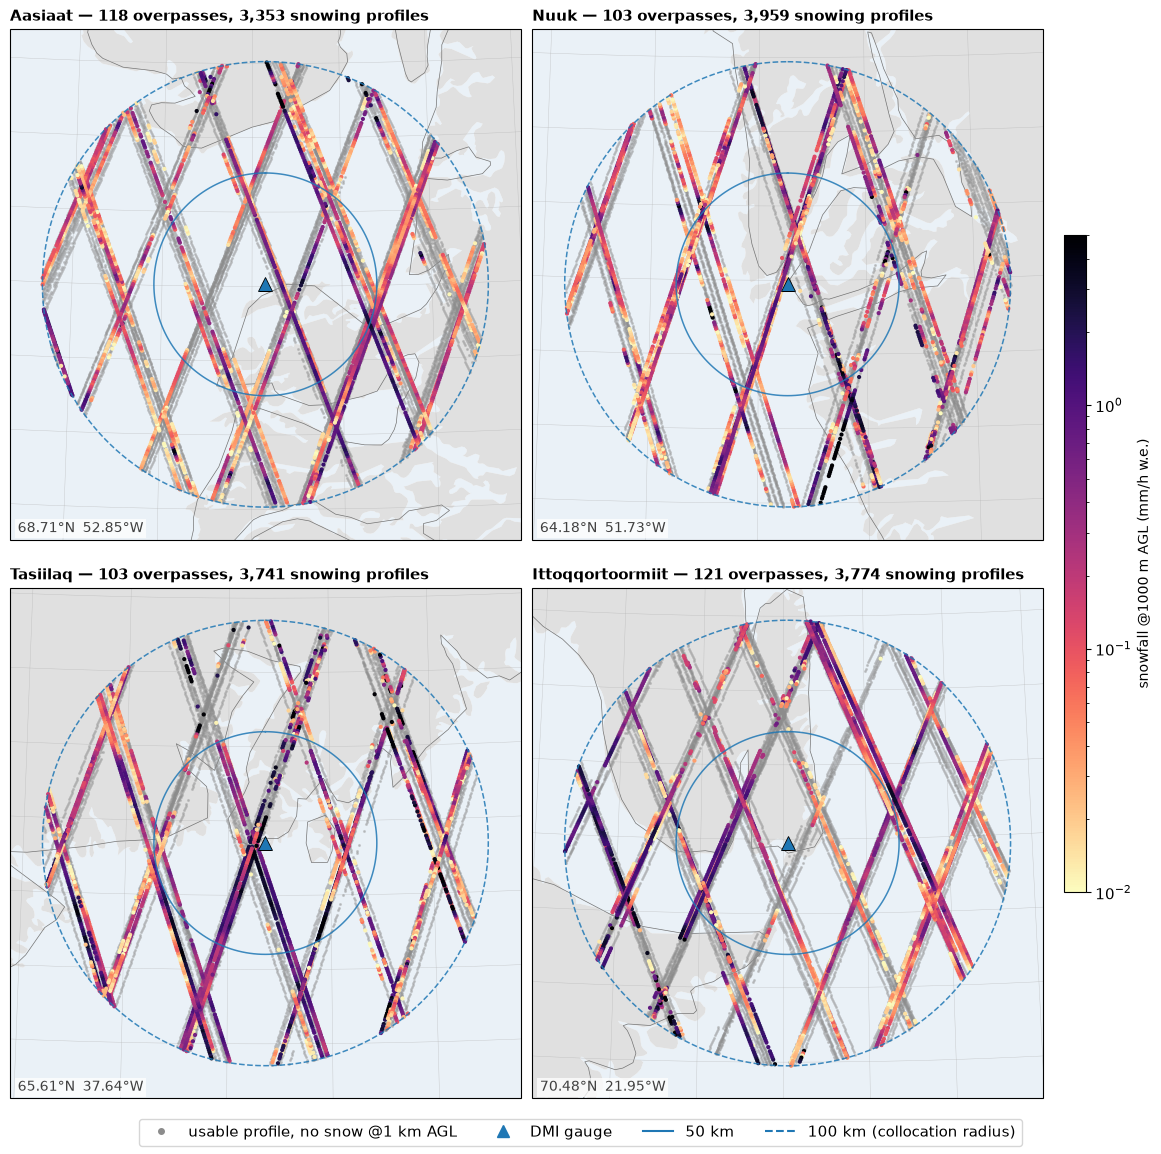

In [2]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm

PANEL_HALF_KM = 115.0        # half-width of each panel (100 km disk + margin)
EARTH_RADIUS_KM = 6371.0
RATE_NORM = LogNorm(vmin=0.01, vmax=5)   # same scale as visualize_earthcare
RATE_CMAP = "magma_r"


def geodesic_circle(center_lat, center_lon, radius_km, n_points=181):
    """Latitudes and longitudes of a true circle of constant great-circle
    radius around a point -- unlike a lat/lon offset it stays circular at
    Greenland latitudes, where a degree of longitude is ~2.5x shorter."""
    bearings = np.linspace(0, 2 * np.pi, n_points)
    angular = radius_km / EARTH_RADIUS_KM
    lat0, lon0 = np.radians(center_lat), np.radians(center_lon)
    ring_lat = np.arcsin(np.sin(lat0) * np.cos(angular)
                         + np.cos(lat0) * np.sin(angular) * np.cos(bearings))
    ring_lon = lon0 + np.arctan2(
        np.sin(bearings) * np.sin(angular) * np.cos(lat0),
        np.cos(angular) - np.sin(lat0) * np.sin(ring_lat))
    return np.degrees(ring_lat), np.degrees(ring_lon)


# --- plotting the four station disks with their EarthCARE transects ---
fig = plt.figure(figsize=(11.5, 11.5), layout="constrained")
panel_axes = []
for panel, (site_name, site) in enumerate(sites.items(), start=1):
    # a station-centred stereographic projection, so the disk is a real circle
    panel_proj = ccrs.Stereographic(central_latitude=site["lat"],
                                    central_longitude=site["lon"])
    ax = fig.add_subplot(2, 2, panel, projection=panel_proj)
    panel_axes.append(ax)
    ax.set_extent([-PANEL_HALF_KM * 1e3, PANEL_HALF_KM * 1e3,
                   -PANEL_HALF_KM * 1e3, PANEL_HALF_KM * 1e3], crs=panel_proj)

    # --- coastlines for context (Natural Earth download can fail offline) ---
    try:
        ax.add_feature(cfeature.OCEAN, facecolor="#eaf1f7", zorder=0)
        ax.add_feature(cfeature.LAND, facecolor="0.88", zorder=0)
        ax.coastlines(resolution="50m", linewidth=0.5, color="0.45", zorder=1)
    except Exception as exc:
        print(f"{site_name}: coastlines unavailable:", exc)
    # graticule without labels: on a station-centred stereographic panel
    # cartopy places lat/lon labels inconsistently (right side on some panels,
    # none on others), so the coordinates go in the corner box instead
    ax.gridlines(linewidth=0.3, color="0.7", alpha=0.7)

    # # --- the profiles inside the disk, split by whether they were snowing ---
    in_disk = site["profile_usable"] & (site["profile_distance_km"] <= 100)
    disk_lat = site["profile_lat"][in_disk]
    disk_lon = site["profile_lon"][in_disk]
    disk_rate = site["profile_snowfall_mmhr"][in_disk]
    is_snowing = disk_rate > SNOW_THRESHOLD_MMHR
    ax.scatter(disk_lon[~is_snowing], disk_lat[~is_snowing], s=1.5, c="0.55",
               alpha=0.35, transform=ccrs.PlateCarree(), zorder=2)
    ax.scatter(disk_lon[is_snowing], disk_lat[is_snowing], s=4,
               c=disk_rate[is_snowing], cmap=RATE_CMAP, norm=RATE_NORM,
               transform=ccrs.PlateCarree(), zorder=3)

    # --- the collocation rings (100 km dashed, 50 km solid) and the gauge ---
    for radius_km, ring_style in [(50, "-"), (100, "--")]:
        ring_lat, ring_lon = geodesic_circle(site["lat"], site["lon"], radius_km)
        ax.plot(ring_lon, ring_lat, ring_style, color="tab:blue", lw=1.1,
                alpha=0.85, transform=ccrs.PlateCarree(), zorder=4)
    ax.plot(site["lon"], site["lat"], "^", ms=10, color="tab:blue",
            markeredgecolor="k", markeredgewidth=0.6,
            transform=ccrs.PlateCarree(), zorder=5)

    # --- panel labels: what was sampled here, and where "here" is ---
    ax.set_title(f"{site_name.title()} — "
                 f"{len(site['overpasses'])} overpasses, "
                 f"{int(is_snowing.sum()):,} snowing profiles",
                 loc="left", fontsize=11, fontweight="bold")
    ax.text(0.015, 0.015, f"{site['lat']:.2f}°N  {abs(site['lon']):.2f}°W",
            transform=ax.transAxes, fontsize=10, color="0.25",
            bbox=dict(fc="white", ec="none", alpha=0.75, pad=1.8), zorder=6)

# --- one shared colour bar and legend for the whole figure ---
cbar = fig.colorbar(ScalarMappable(norm=RATE_NORM, cmap=RATE_CMAP), ax=panel_axes,
             shrink=0.6, pad=0.02, aspect=30,
             label="snowfall @1000 m AGL (mm/h w.e.)")
cbar.ax.tick_params(labelsize=11)
fig.legend(handles=[
    plt.Line2D([], [], marker="o", ls="", ms=4, color="0.55",
               label="usable profile, no snow @1 km AGL"),
    plt.Line2D([], [], marker="^", ls="", ms=8, color="tab:blue",
               label="DMI gauge"),
    plt.Line2D([], [], ls="-", color="tab:blue", label="50 km"),
    plt.Line2D([], [], ls="--", color="tab:blue",
               label="100 km (collocation radius)"),
], loc="outside lower center", ncol=4, fontsize=11)
# fig.suptitle("EarthCARE sampling geometry — every usable profile within "
#              "100 km of each gauge, 2025 (Jan–Jun, Oct–Dec)", fontsize=11)
fig.savefig("../figures/eo_dmi_station_maps.png", dpi=300, bbox_inches="tight")
plt.show()

## 2 · Detection agreement per station

Same contingency as the Aasiaat notebook (gauge reference: snow-phase precip
> 0 within ±30 min; overpasses with no gauge data in the window are
excluded). Shown for the two bracketing criteria.

In [3]:
# contingency() comes from src/validation.py

# --- score every site under the two satellite criteria (<=100 km, <=30 km) ---
detection_rows = []
for site_name, site in sites.items():
    # only overpasses that actually have gauge data in the +/-30 min window
    scored = site["overpasses"][site["overpasses"].gauge_n_stamps_pm30 > 0]
    gauge_snowing = scored["gauge_snow_pm30_mm"] > 0
    for criterion, sat_snowing in [("any <=100 km", scored["sat_any_100km"]),
                                   ("any <=30 km", scored["sat_any_30km"])]:
        counts = contingency(sat_snowing.values, gauge_snowing.values)
        detection_rows.append(dict(
            site=site_name, criterion=criterion, n=len(scored),
            gauge_events=int(gauge_snowing.sum()), **counts))
detection_table = pd.DataFrame(detection_rows)
pd.set_option("display.width", 200)
detection_table

,site,criterion,n,gauge_events,hit,miss,false_alarm,correct_neg,POD,FAR
0,aasiaat,any <=100 km,118,22,15,7,43,53,0.68,0.74
1,aasiaat,any <=30 km,118,22,4,18,3,93,0.18,0.43
2,nuuk,any <=100 km,102,9,8,1,57,36,0.89,0.88
3,nuuk,any <=30 km,102,9,3,6,11,82,0.33,0.79
4,tasiilaq,any <=100 km,72,4,3,1,46,22,0.75,0.94
5,tasiilaq,any <=30 km,72,4,2,2,5,63,0.50,0.71
6,ittoqqortoormiit,any <=100 km,67,5,4,1,31,31,0.80,0.89
7,ittoqqortoormiit,any <=30 km,67,5,0,5,3,59,0.00,1.00


## 3 · FSS across sites

All three configurations from the Aasiaat events notebook, per site:
**primary** θ = 0.1 mm/h with T = ±1 h, the loose-threshold sensitivity
(θ = 0.01), and the advective-window sensitivity (T = L / v, station 10-m
wind at the overpass hour, floored at 2 m/s). Per-L useful-skill reference
from each site's own base rate; n-labels on the primary curve.

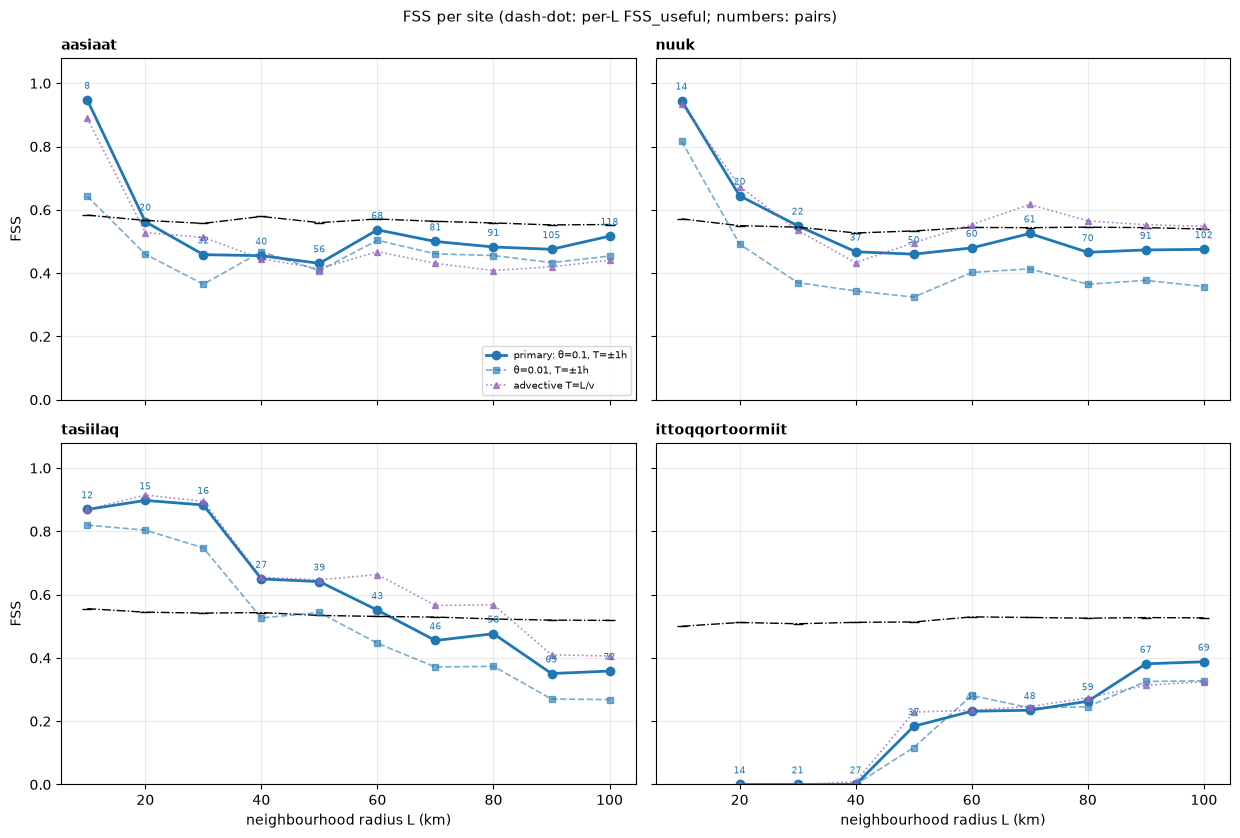

In [4]:
# FSS_RADII, the thresholds and fss_score come from src -- see the loader
# (legend label, satellite threshold theta, advective window?, line style)
FSS_CONFIGS = [
    ("primary: θ=0.1, T=±1h", THETA_FSS, False,
     dict(color="tab:blue", lw=2, marker="o")),
    ("θ=0.01, T=±1h", SNOW_THRESHOLD_MMHR, False,
     dict(color="tab:blue", lw=1.2, ls="--", marker="s", ms=4, alpha=0.6)),
    ("advective T=L/v", THETA_FSS, True,
     dict(color="tab:purple", lw=1.2, ls=":", marker="^", ms=4, alpha=0.8)),
]


def site_pairs(site, radius_km, theta, advective):
    """(p_sat, p_gauge) pairs for one site: the shared fss_pairs with a fixed
    +/-1 h window, or the advective T = L/v window driven by the station's
    own 10-m wind (parameter 301) when advective is True."""
    half_window = (advective_window(site["station_hourly"]["301"], radius_km)
                   if advective else pd.Timedelta("1h"))
    return fss_pairs(site, radius_km, theta, half_window)


# --- plotting the 4-station FSS curves (one panel per site, 3 configs each) ---
pairs_by_site = {}       # (site_name, config label, L) -> pairs; reused when pooling
fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.5), sharex=True, sharey=True)
for ax, (site_name, site) in zip(axes.flat, sites.items()):
    for label, theta, advective, style in FSS_CONFIGS:
        # FSS at every radius for this configuration
        fss_values = []
        for radius_km in FSS_RADII:
            pairs = site_pairs(site, radius_km, theta, advective)
            pairs_by_site[(site_name, label, radius_km)] = pairs
            fss_values.append(fss_score(pairs))
        ax.plot(FSS_RADII, fss_values, label=label, **style)
        if label.startswith("primary"):
            # per-L useful-skill reference FSS_useful = 0.5 + f0/2, and pair counts
            gauge_base_rates = [
                pairs_by_site[(site_name, label, radius_km)][:, 1].mean()
                if len(pairs_by_site[(site_name, label, radius_km)]) else np.nan
                for radius_km in FSS_RADII]
            ax.plot(FSS_RADII, 0.5 + np.array(gauge_base_rates) / 2, "k-.", lw=1,
                    marker="_", ms=7)
            for radius_km, fss_value in zip(FSS_RADII, fss_values):
                n_pairs = len(pairs_by_site[(site_name, label, radius_km)])
                if np.isfinite(fss_value):
                    ax.annotate(f"{n_pairs}", (radius_km, fss_value),
                                textcoords="offset points", xytext=(0, 8),
                                ha="center", fontsize=6.5, color="tab:blue")
    ax.set_ylim(0, 1.08)
    ax.set_title(site_name, loc="left", fontsize=10, fontweight="bold")
    ax.grid(alpha=0.25)

# --- shared axis labels, legend, save ---
axes[0, 0].legend(fontsize=7, loc="lower right")
for ax in axes[1]:
    ax.set_xlabel("neighbourhood radius L (km)")
for ax in axes[:, 0]:
    ax.set_ylabel("FSS")
fig.suptitle("FSS per site (dash-dot: per-L FSS_useful; numbers: pairs)",
             fontsize=11)
fig.savefig("../figures/eo_dmi_fss_stations.png", dpi=300,
            bbox_inches="tight")
plt.tight_layout()
plt.show()

### 3b · The generalized curve: all overpasses, all stations

Every overpass of every site enters one FSS computation — each pair is
(satellite fraction within L of *its* station, that station's gauge
fraction). Pooling is legitimate because FSS is a sum over pairs; it answers
the general question *"at what scale does EarthCARE agree with a Greenland
coastal gauge that it is snowing?"* with every pair we have (~4× any single
site), at the cost of averaging over site-specific behaviour. The useful-skill
line uses the pooled base rate per L.

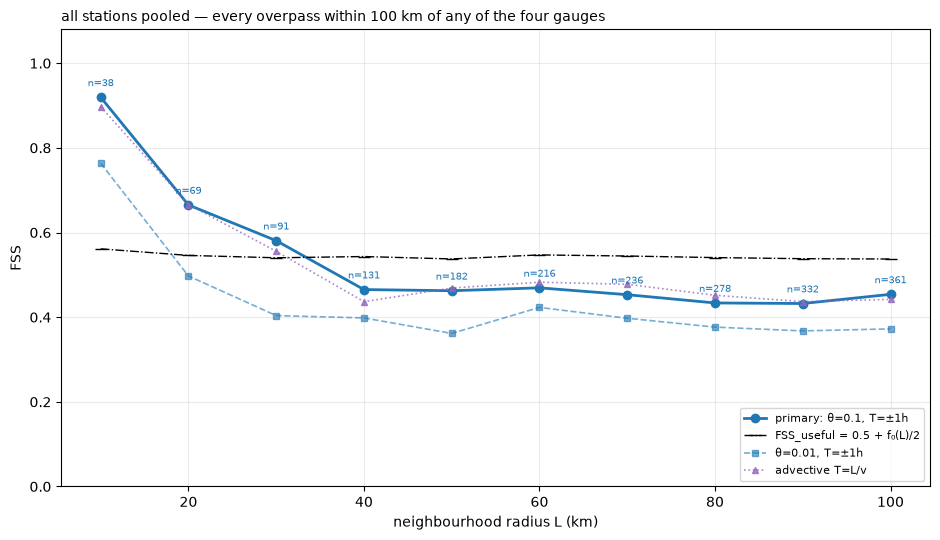

In [5]:
def pooled_pairs(label, radius_km):
    """Stack the (p_sat, p_gauge) pairs of all four sites for one FSS
    configuration and radius; an empty (0, 2) array if no site has pairs."""
    stacks = [pairs_by_site[(site_name, label, radius_km)] for site_name in sites
              if len(pairs_by_site[(site_name, label, radius_km)])]
    return np.vstack(stacks) if stacks else np.empty((0, 2))


# --- plotting the pooled all-stations FSS curves ---
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for label, theta, advective, style in FSS_CONFIGS:
    fss_values, n_pairs, gauge_base_rates = [], [], []
    for radius_km in FSS_RADII:
        pooled = pooled_pairs(label, radius_km)
        fss_values.append(fss_score(pooled))
        n_pairs.append(len(pooled))
        gauge_base_rates.append(pooled[:, 1].mean() if len(pooled) else np.nan)
    ax.plot(FSS_RADII, fss_values, label=label, **style)
    if label.startswith("primary"):
        # useful-skill reference and pair counts for the primary curve only
        ax.plot(FSS_RADII, 0.5 + np.array(gauge_base_rates) / 2, "k-.", lw=1,
                marker="_", ms=8, label="FSS_useful = 0.5 + f₀(L)/2")
        for radius_km, fss_value, n in zip(FSS_RADII, fss_values, n_pairs):
            if np.isfinite(fss_value):
                ax.annotate(f"n={n}", (radius_km, fss_value),
                            textcoords="offset points", xytext=(0, 8),
                            ha="center", fontsize=7, color="tab:blue")
ax.set_ylim(0, 1.08)
ax.set_xlabel("neighbourhood radius L (km)")
ax.set_ylabel("FSS")
ax.set_title("all stations pooled — every overpass within 100 km of any "
             "of the four gauges", loc="left", fontsize=10)
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="lower right")
fig.savefig("../figures/eo_dmi_fss_all_stations.png", dpi=300,
            bbox_inches="tight")
plt.tight_layout()
plt.show()

### 3c · Steering-wind advection: T = L/v with the 850 hPa wind

The advective sensitivity above uses the **station 10-m wind** — the
worst-supported choice in the literature. Neither advective-matching
precedent uses surface wind: Souverijns et al. (2018) take the reanalysis
wind at 300 m a.g.l., Lemonnier et al. (2019) the radiosonde 0–3 km layer
mean, and precipitation-system motion classically correlates best with the
~700–850 hPa **steering-level** flow (Ligda & Mayhew 1954; Niziol 1987 for
snowbands). Coastal Greenland surface winds are especially poor proxies —
katabatic and fjord-channeled, decoupled from what moves the snowfield.

This section re-runs the advective window with **v = the 850 hPa wind speed
at the overpass hour** (ECMWF IFS 0.25° archived analyses via the open-meteo
historical archive — ERA5-grade for a steering scalar; prefetched to
`data/in-situ/era5_wind850_2025.csv`). Everything else is unchanged, so the
three pooled curves below differ only in the wind that sets the window.

*Taylor caveat, stated once for all advective variants:* the frozen-field
conversion assumes the snowfield translates without evolving. For
terrain-anchored coastal snowfall that assumption leaks — small-scale
precipitation decorrelates in tens of minutes (Zawadzki 1973) — so long
windows are more defensible for climatological than for event-wise scores.

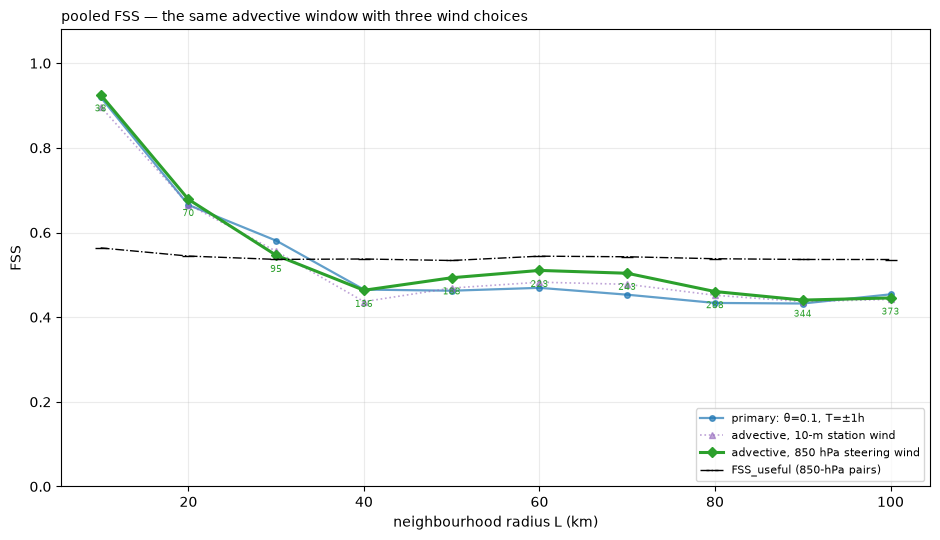

,L_km,fss_850hPa,n_pairs
0,10,0.926,38
1,20,0.678,70
2,30,0.546,95
3,40,0.464,136
4,50,0.493,188
5,60,0.510,223
6,70,0.504,243
7,80,0.461,288
8,90,0.440,344
9,100,0.445,373


In [6]:
# --- hourly 850 hPa wind speed per site (ECMWF IFS via open-meteo),
#     indexed by (site, timestamp) ---
wind_850hpa = (pd.read_csv("../data/in-situ/era5_wind850_2025.csv",
                           parse_dates=["ts"])
               .set_index(["site", "ts"])["ws850_ms"])


def fss_pairs_steering_wind(site_name, site, radius_km, theta=THETA_FSS):
    """Like site_pairs(advective=True), but the T = L/v window is driven by
    the 850 hPa steering wind at the overpass hour instead of the 10-m wind
    -- the same shared fss_pairs, only the wind series changes."""
    return fss_pairs(site, radius_km, theta,
                     half_window=advective_window(wind_850hpa.loc[site_name],
                                                  radius_km))


def pooled_pairs_steering_wind(radius_km, theta=THETA_FSS):
    """Stack the 850 hPa-window pairs of all four sites for one radius."""
    stacks = [fss_pairs_steering_wind(site_name, site, radius_km, theta)
              for site_name, site in sites.items()]
    stacks = [p for p in stacks if len(p)]
    return np.vstack(stacks) if stacks else np.empty((0, 2))


fig, ax = plt.subplots(figsize=(9.5, 5.5))
# --- reference curves from section 3b (fixed window, 10-m advective) ---
for label, style in [("primary: θ=0.1, T=±1h",
                      dict(color="tab:blue", lw=1.6, marker="o", ms=4, alpha=0.7)),
                     ("advective T=L/v",
                      dict(color="tab:purple", lw=1.2, ls=":", marker="^",
                           ms=4, alpha=0.6))]:
    fss_values = [fss_score(pooled_pairs(label, radius_km))
                  for radius_km in FSS_RADII]
    curve_name = label if "primary" in label else "advective, 10-m station wind"
    ax.plot(FSS_RADII, fss_values, label=curve_name, **style)

# --- new curve: the same advective window driven by the 850 hPa wind ---
fss_850, n_pairs_850, gauge_base_rates_850 = [], [], []
for radius_km in FSS_RADII:
    pooled = pooled_pairs_steering_wind(radius_km)
    fss_850.append(fss_score(pooled))
    n_pairs_850.append(len(pooled))
    gauge_base_rates_850.append(pooled[:, 1].mean() if len(pooled) else np.nan)
ax.plot(FSS_RADII, fss_850, color="tab:green", lw=2.2, marker="D", ms=5,
        label="advective, 850 hPa steering wind")
ax.plot(FSS_RADII, 0.5 + np.array(gauge_base_rates_850) / 2, "k-.", lw=1,
        marker="_", ms=8, label="FSS_useful (850-hPa pairs)")
for radius_km, fss_value, n in zip(FSS_RADII, fss_850, n_pairs_850):
    if np.isfinite(fss_value):
        ax.annotate(f"{n}", (radius_km, fss_value), textcoords="offset points",
                    xytext=(0, -12), ha="center", fontsize=6.5,
                    color="tab:green")
ax.set_ylim(0, 1.08)
ax.set_xlabel("neighbourhood radius L (km)")
ax.set_ylabel("FSS")
ax.set_title("pooled FSS — the same advective window with three wind choices",
             loc="left", fontsize=10)
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="lower right")
fig.savefig("../figures/eo_dmi_fss_wind850.png", dpi=300,
            bbox_inches="tight")
plt.tight_layout()
plt.show()

# --- the 850 hPa curve as a table ---
wind850_table = pd.DataFrame({"L_km": FSS_RADII,
                              "fss_850hPa": np.round(fss_850, 3),
                              "n_pairs": n_pairs_850})
wind850_table

### 3d · Raising the satellite threshold: a sublimation correction?

The θ = 0.1 mm/h harmonization matches the gauge's *resolution*, but the two
instruments measure at different heights: the satellite at ~1 km AGL, the
gauge after the snow has crossed the radar's blind zone — where **sub-cloud
sublimation eats part of the flux** (Souverijns et al. 2018 attributed a 25%
loss to the 1200→300 m height difference alone, and our virga case studies
showed total loss). 0.1 mm/h aloft therefore does *not* mean 0.1 mm/h at the
gauge.

Our own accumulation ratios calibrate the expectation: the satellite reads
×2–3.7 the gauge over common months, so a gauge-detectable 0.1 mm/h at the
surface corresponds to roughly **0.2–0.4 mm/h at the reference level**. If
the sublimation logic is right, FSS should *improve* as θ rises into that
band (shedding aloft-only detections faster than real matches) and degrade
beyond it (losing genuine events). All curves below use the 850 hPa
advective window from 3c.

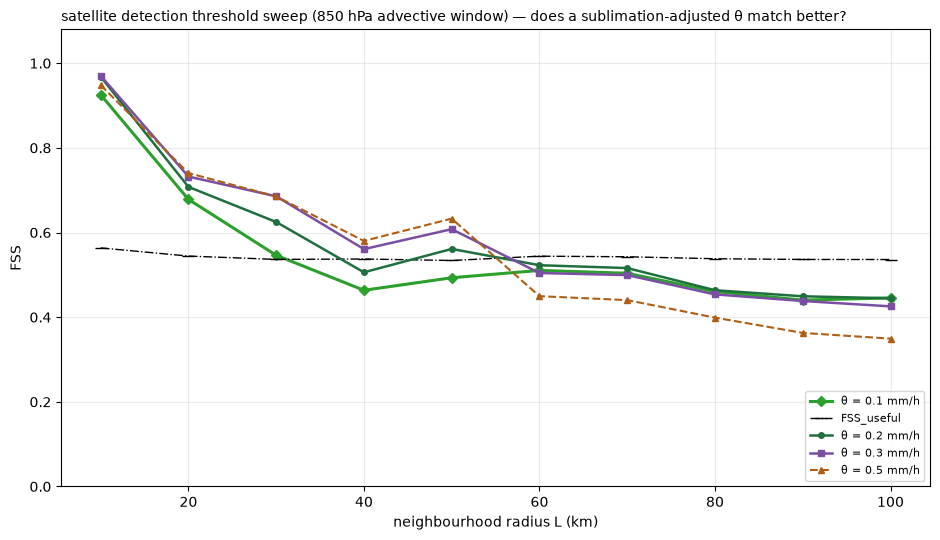

theta,0.1,0.2,0.3,0.5
L_km,,,,
10,0.926,0.968,0.970,0.948
20,0.678,0.708,0.732,0.740
30,0.546,0.625,0.686,0.685
40,0.464,0.506,0.561,0.580
50,0.493,0.561,0.608,0.633
60,0.510,0.523,0.504,0.450
70,0.504,0.516,0.499,0.440
80,0.461,0.464,0.454,0.399
90,0.440,0.449,0.438,0.363


In [7]:
THETA_SWEEP = [0.1, 0.2, 0.3, 0.5]      # satellite thresholds (mm/h) to try
sweep_styles = {0.1: dict(color="tab:green", lw=2.2, marker="D", ms=5),
                0.2: dict(color="#1f6f3f", lw=1.8, marker="o", ms=4),
                0.3: dict(color="#7a4fa3", lw=1.8, marker="s", ms=4),
                0.5: dict(color="#b05e14", lw=1.5, ls="--", marker="^", ms=4)}

# --- plotting pooled FSS vs L for each theta, all with the 850 hPa window ---
fig, ax = plt.subplots(figsize=(9.5, 5.5))
sweep_rows = []
for theta in THETA_SWEEP:
    fss_values, gauge_base_rates = [], []
    for radius_km in FSS_RADII:
        pooled = pooled_pairs_steering_wind(radius_km, theta=theta)
        fss_values.append(fss_score(pooled))
        gauge_base_rates.append(pooled[:, 1].mean() if len(pooled) else np.nan)
        sweep_rows.append(dict(theta=theta, L_km=radius_km,
                               FSS=round(fss_values[-1], 3)
                               if np.isfinite(fss_values[-1]) else np.nan))
    ax.plot(FSS_RADII, fss_values, label=f"θ = {theta:g} mm/h",
            **sweep_styles[theta])
    if theta == 0.1:
        # p_gauge does not depend on theta, so one FSS_useful line is enough
        ax.plot(FSS_RADII, 0.5 + np.array(gauge_base_rates) / 2, "k-.", lw=1,
                marker="_", ms=8, label="FSS_useful")
ax.set_ylim(0, 1.08)
ax.set_xlabel("neighbourhood radius L (km)")
ax.set_ylabel("FSS")
ax.set_title("satellite detection threshold sweep (850 hPa advective "
             "window) — does a sublimation-adjusted θ match better?",
             loc="left", fontsize=10)
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="lower right")
fig.savefig("../figures/eo_dmi_fss_theta_sweep.png", dpi=300,
            bbox_inches="tight")
plt.tight_layout()
plt.show()

# --- FSS(L, theta) as a table: rows = radius, columns = theta ---
theta_table = (pd.DataFrame(sweep_rows)
               .pivot(index="L_km", columns="theta", values="FSS"))
theta_table

### 3e · The pooled curve with the adjusted threshold

Section 3b pooled all four stations at the gauge-harmonized θ = 0.1 mm/h;
3c showed the 850 hPa steering wind buys a little in the 50–70 km band; 3d
showed the real lever is the **threshold**, with FSS peaking near θ = 0.3.
This section rebuilds the 3b plot with those lessons applied, as a
progression in which each curve answers one question:

- **θ = 0.01 mm/h, T = ±1 h** — the unharmonized baseline this notebook
  started from, kept as the reference for how far threshold choice moves the
  result.
- **θ = 0.1 mm/h, T = ±1 h** — the gauge-harmonized threshold of section 3b,
  matched to the gauge's 0.1 mm/h resolution floor. This is the starting
  curve: the honest default before any sublimation argument is made.
- **θ = 0.3 mm/h, T = ±1 h** — the sublimation-adjusted threshold on the
  same simple time window. If this alone lifts the curve, the gain found in
  3d is a threshold effect and not a window effect.
- **θ = 0.3 mm/h, advective T = L/v (850 hPa)** — both adjustments at once.

The physical argument for raising θ: a rate of 0.1 mm/h
retrieved at 1000 m AGL does not arrive at the gauge as 0.1 mm/h. It has to
survive the CPR blind zone below ~700 m, where sublimation and evaporation
thin the flux, so the satellite threshold that *corresponds* to the gauge's
0.1 mm/h resolution floor must be higher than 0.1. The accumulation ratios of
section 4 (satellite ≈ 2–3.7× the gauge) independently predict an equivalent
threshold of roughly 0.2–0.4 — θ = 0.3 sits in that band, which is why it is
worth a dedicated pooled curve rather than one line of a sweep.

Two useful-skill references are drawn because the two window definitions
select slightly different pair populations (the steering wind is rarely calm,
so its windows admit a few more overpasses), and each curve must be read
against the base rate of its own pairs.

**Reading the curves.** The useful-skill reference sits essentially flat at
**0.54** for both window definitions (`useful_T1h` / `useful_850` in the
table): the gauge base rate depends on the time window, not on the radius, so
only the pair population changes across L. Read as a ladder, at L = 30 km the
four curves go **0.404 → 0.581 → 0.672 → 0.686**, and at L = 50 km
**0.362 → 0.462 → 0.551 → 0.608**.

- **Harmonizing to the gauge floor is the mandatory step and the largest
  one.** Going from θ = 0.01 to θ = 0.1 adds +0.16 to +0.18 at 10–30 km
  (0.920 / 0.665 / 0.581) and lifts the skillful scale from 10 km to ~30 km.
  This step is not a tuning choice: at θ = 0.01 the two sides are
  incommensurate binaries, since the gauge physically cannot report the rates
  the satellite is being credited for.
- **The sublimation adjustment adds a second, smaller step — and only at
  short range.** θ = 0.1 → 0.3 is worth +0.07 at 20 km, +0.09 at 30 km and
  +0.09 at 50 km, but it **reverses beyond 60 km**: 0.436 vs 0.469 at 60 km
  and 0.424 vs 0.454 at 100 km. Past the decorrelation scale a higher
  threshold stops removing sublimating virga and starts deleting real events.
- **The steering wind is the smallest lever, and it acts in the middle
  band**: ≤ 0.02 inside 30 km, but +0.04 at 40 km, +0.06 at 50 km and +0.07
  at 60 km. That is what decides the margin — the θ = 0.3 fixed-window curve
  straddles the useful line there (0.519 at 40 km, just *below* 0.543; 0.551
  at 50 km, just above), while the 850 hPa curve clears it at both (0.561 and
  0.608).

So the skillful scale goes **10 km → 30 km → ~50 km** as the three
adjustments are applied in turn, and beyond 60 km every curve falls to
0.42–0.50 and stays below useful skill. That is the same two-regime picture
as 3d, now with the intermediate step visible: near the gauge the
disagreement is light aloft-snow that never reaches the ground, and a
threshold fixes it; past ~50–60 km the disagreement is spatial displacement,
and none of the three adjustments touches it.

**Three caveats.** (1) θ = 0.3 was *selected* on this same dataset in 3d, so
this section shows what the adjustment buys, not an independent validation of
it — an out-of-sample year would be needed for that. The θ = 0.1 curve does
not share this problem: it is fixed a priori by the gauge's resolution.
(2) The pair count grows with L (n = 38 at 10 km to 361 at 100 km), so the
strong left end rests on few overpasses; the structural caveat from section 3
applies here unchanged. (3) A fixed θ is a detection-equivalence adjustment
standing in for sublimation below the blind zone, not a per-profile
microphysical model.

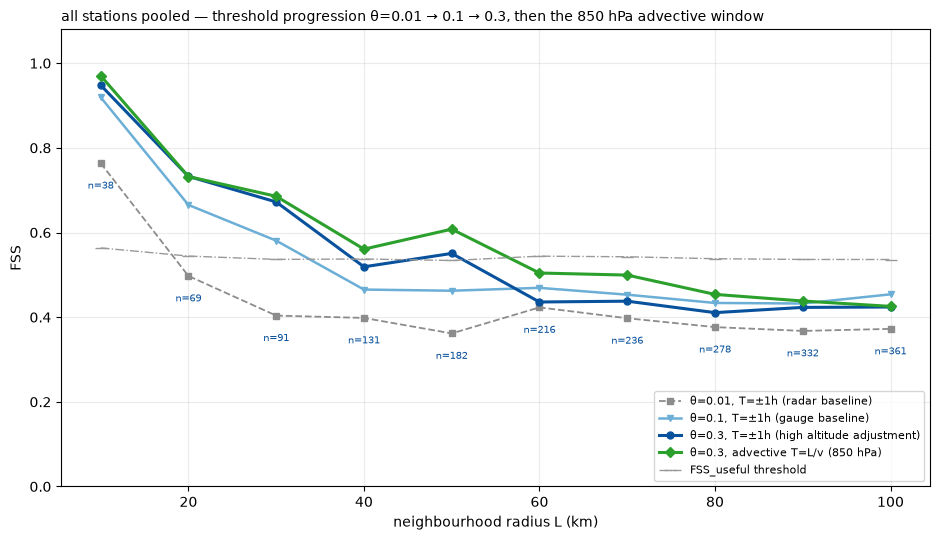

wrote ../results/fss_ladder_curves.csv for presentation.ipynb


curve,"θ=0.01, T=±1h (radar baseline)","θ=0.1, T=±1h (gauge baseline)","θ=0.3, T=±1h (high altitude adjustment)","θ=0.3, advective T=L/v (850 hPa)",useful_T1h,useful_850
L_km,,,,,,
10,0.764,0.920,0.948,0.970,0.561,0.564
20,0.497,0.665,0.733,0.732,0.546,0.544
30,0.404,0.581,0.672,0.686,0.540,0.536
40,0.398,0.465,0.519,0.561,0.543,0.537
50,0.362,0.462,0.551,0.608,0.538,0.534
60,0.423,0.469,0.436,0.504,0.547,0.544
70,0.397,0.453,0.438,0.499,0.544,0.543
80,0.377,0.434,0.411,0.454,0.541,0.538
90,0.368,0.432,0.423,0.438,0.538,0.536


In [8]:
# THETA_ADJUSTED (0.3, the 3d sweep optimum) comes from src/study_config.py

def pooled_pairs_fixed_window(radius_km, theta):
    """Stack the fixed +/-1 h (p_sat, p_gauge) pairs of all four sites for one
    satellite threshold and radius -- the 3b pooling, with theta free."""
    stacks = [fss_pairs(site, radius_km, theta)
              for site in sites.values()]
    stacks = [pairs for pairs in stacks if len(pairs)]
    return np.vstack(stacks) if stacks else np.empty((0, 2))


# (legend label, pair builder, line style) -- ordered as a threshold
# progression, with a light-to-dark blue ramp so the ordering is readable
ADJUSTED_CONFIGS = [
    ("θ=0.01, T=±1h (radar baseline)",
     lambda L: pooled_pairs_fixed_window(L, SNOW_THRESHOLD_MMHR),
     dict(color="0.55", lw=1.3, ls="--", marker="s", ms=4)),
    (f"θ={THETA_FSS:g}, T=±1h (gauge baseline)",
     lambda L: pooled_pairs_fixed_window(L, THETA_FSS),
     dict(color="#6baed6", lw=1.8, marker="v", ms=4.5)),
    (f"θ={THETA_ADJUSTED:g}, T=±1h (high altitude adjustment)",
     lambda L: pooled_pairs_fixed_window(L, THETA_ADJUSTED),
     dict(color="#08519c", lw=2.2, marker="o", ms=5)),
    (f"θ={THETA_ADJUSTED:g}, advective T=L/v (850 hPa)",
     lambda L: pooled_pairs_steering_wind(L, theta=THETA_ADJUSTED),
     dict(color="tab:green", lw=2.2, marker="D", ms=5)),
]

# --- pooled FSS at every radius for each of the three configurations ---
adjusted_curves, adjusted_rows = {}, []
for label, build_pooled, _ in ADJUSTED_CONFIGS:
    fss_values, n_pairs, gauge_base_rates = [], [], []
    for radius_km in FSS_RADII:
        pooled = build_pooled(radius_km)
        fss_values.append(fss_score(pooled))
        n_pairs.append(len(pooled))
        gauge_base_rates.append(pooled[:, 1].mean() if len(pooled) else np.nan)
        adjusted_rows.append(dict(curve=label, L_km=radius_km,
                                  n_pairs=len(pooled),
                                  FSS=round(fss_values[-1], 3)
                                  if np.isfinite(fss_values[-1]) else np.nan))
    adjusted_curves[label] = dict(fss=fss_values, n=n_pairs,
                                  f0=gauge_base_rates)

# --- plotting the pooled curves under the adjusted threshold ---
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for label, _, style in ADJUSTED_CONFIGS:
    curve = adjusted_curves[label]
    ax.plot(FSS_RADII, curve["fss"], label=label, **style)

# one useful-skill reference per window definition (the two pair populations
# differ slightly, so each curve is read against its own base rate)
fixed_f0 = adjusted_curves[f"θ={THETA_ADJUSTED:g}, T=±1h (high altitude adjustment)"]["f0"]
steering_f0 = adjusted_curves[
    f"θ={THETA_ADJUSTED:g}, advective T=L/v (850 hPa)"]["f0"]
# ax.plot(FSS_RADII, 0.5 + np.array(fixed_f0) / 2, "k-.", lw=1, marker="_",
#         ms=8, label="FSS_useful threshold")
ax.plot(FSS_RADII, 0.5 + np.array(steering_f0) / 2, color="0.6", ls="-.",
        lw=1, marker="_", ms=8, label="FSS_useful threshold")

# pair counts: theta changes p_sat but never whether a pair exists, so all
# three fixed-window curves share these n; anchored under the lowest curve at
# each radius so the labels never sit on a line
primary = adjusted_curves[f"θ={THETA_ADJUSTED:g}, T=±1h (high altitude adjustment)"]
lowest_curve = np.nanmin([adjusted_curves[label]["fss"]
                          for label, _, _ in ADJUSTED_CONFIGS], axis=0)
for radius_km, floor_value, n in zip(FSS_RADII, lowest_curve, primary["n"]):
    if np.isfinite(floor_value):
        ax.annotate(f"n={n}", (radius_km, floor_value),
                    textcoords="offset points", xytext=(0, -13), ha="center",
                    va="top", fontsize=7, color="#08519c")

ax.set_ylim(0, 1.08)
ax.set_xlabel("neighbourhood radius L (km)")
ax.set_ylabel("FSS")
ax.set_title("all stations pooled — threshold progression θ=0.01 → 0.1 → "
             f"{THETA_ADJUSTED:g}, then the 850 hPa advective window",
             loc="left", fontsize=10)
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="lower right")
fig.savefig("../figures/eo_dmi_fss_pooled_theta03.png", dpi=300,
            bbox_inches="tight")
plt.tight_layout()
plt.show()

# --- export the ladder: presentation.ipynb re-plots these curves one
#     slide at a time without re-running the FSS sweeps ---
ladder_rows = []
for step, (label, _, _) in enumerate(ADJUSTED_CONFIGS, start=1):
    curve = adjusted_curves[label]
    for radius_km, fss_value, n, f0 in zip(FSS_RADII, curve["fss"],
                                           curve["n"], curve["f0"]):
        ladder_rows.append(dict(step=step, curve=label, L_km=radius_km,
                                n_pairs=n, FSS=fss_value, f0=f0))
pd.DataFrame(ladder_rows).to_csv("../results/fss_ladder_curves.csv",
                                 index=False)
print("wrote ../results/fss_ladder_curves.csv for presentation.ipynb")

# --- the same curves as a table, with both useful-skill references so the
#     crossings can be read exactly rather than off the figure ---
adjusted_table = (pd.DataFrame(adjusted_rows)
                  .pivot(index="L_km", columns="curve", values="FSS"))
adjusted_table["useful_T1h"] = np.round(0.5 + np.array(fixed_f0) / 2, 3)
adjusted_table["useful_850"] = np.round(0.5 + np.array(steering_f0) / 2, 3)
adjusted_table

### 3f · A first look at how ERA5 does on the same question

Every curve above scores **EarthCARE** against the gauge. The model notebook
(`compare_model_earthcare_dmi`, section 2) scores **ERA5's nearest grid cell**
against the same gauges with the same metric, and the result is a single
number rather than a curve — a cell sitting on a station has no radius to
vary. Pooled over all four stations and all 29 171 scored hours of 2025 it is
**FSS = 0.408**, against a useful-skill line of 0.532.

Putting that point on these axes asks a blunt question: *at a comparable
spatial scale, does a 25 km reanalysis cell predict what the gauge sees any
better than a satellite curtain does?* Both are scored against the same
reference, and — the reason the vertical comparison means anything — both
useful-skill lines land in the same place (0.532 for the ERA5 pairs, 0.537–0.561
for the EarthCARE pairs), because the reference is the gauge in both cases.

**Read this as an order-of-magnitude first step, not a like-for-like
benchmark.** Three differences are real and all of them deserve to be stated
before the point is interpreted:

1. **Different construction, and this is the big one.** EarthCARE's
   $p_{sat}$ is a *continuous* fraction over many profiles in the
   neighbourhood, so partial overlap earns partial credit. The ERA5 point is
   **binary on both sides** (the cell either snows that hour or it does not),
   and binary pairs earn no partial credit — which depresses FSS on its own,
   independently of skill.
2. **Different sample.** The curves use the ~360 EarthCARE overpass windows;
   the ERA5 point uses all 29 171 gauge-valid hours of the year, a far larger
   and more representative sample that includes the many quiet hours no
   satellite happened to observe.
3. **Nominal placement on the x-axis.** ERA5's 0.25° grid is ~25 km, so the
   point is drawn at L = 25 km as an effective scale. The cells actually sit
   2.5–23.5 km from their stations and average over a square, not a disk of
   that radius.

The proper like-for-like version — ERA5 scored with the same ±1 h fractional
window on the same overpasses — is the natural next step, and section 4 of
the model notebook already computes its contingency form (POD 0.57 /
FAR 0.65 on the 359 overpass windows).

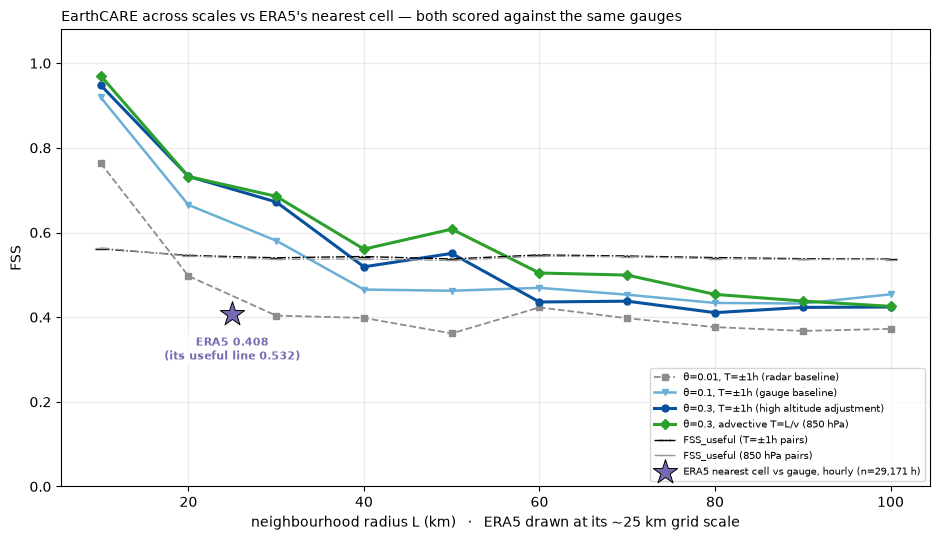

,"θ=0.01, T=±1h (radar baseline)","θ=0.1, T=±1h (gauge baseline)","θ=0.3, T=±1h (high altitude adjustment)","θ=0.3, advective T=L/v (850 hPa)"
L=20 km,0.497,0.665,0.733,0.732
L=30 km,0.404,0.581,0.672,0.686
ERA5 point (L~25 km),0.408,0.408,0.408,0.408


In [9]:
from pathlib import Path

# --- the ERA5 point-scale score, written by compare_model_earthcare_dmi §2 ---
ERA5_NOMINAL_SCALE_KM = 25.0      # ERA5's ~0.25 deg grid, as an effective radius
ERA5_COLOR = "#756bb1"            # the model colour used in the model notebook
# fallback keeps this section runnable standalone; the CSV is the source of truth
ERA5_FALLBACK = dict(FSS=0.408, FSS_useful=0.532, n_hours=29171)

era5_point_path = Path("../results/era5_gauge_point_fss.csv")
if era5_point_path.exists():
    era5_point = (pd.read_csv(era5_point_path)
                  .set_index("criterion").loc["exact hour"])
else:
    era5_point = pd.Series(ERA5_FALLBACK)
    print(f"NOTE: {era5_point_path} not found -- using the documented values "
          "from compare_model_earthcare_dmi; re-run that notebook to refresh.")
era5_fss = float(era5_point["FSS"])
era5_useful = float(era5_point["FSS_useful"])
era5_hours = int(era5_point["n_hours"])

# --- plotting the 3e curves again, with the ERA5 point overlaid ---
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for label, _, style in ADJUSTED_CONFIGS:
    ax.plot(FSS_RADII, adjusted_curves[label]["fss"], label=label, **style)
ax.plot(FSS_RADII, 0.5 + np.array(fixed_f0) / 2, "k-.", lw=1, marker="_", ms=8,
        label="FSS_useful (T=±1h pairs)")
ax.plot(FSS_RADII, 0.5 + np.array(steering_f0) / 2, color="0.6", ls="-.",
        lw=1, marker="_", ms=8, label="FSS_useful (850 hPa pairs)")

# the ERA5 nearest-cell score: one point, drawn at its nominal grid scale
ax.scatter([ERA5_NOMINAL_SCALE_KM], [era5_fss], marker="*", s=340,
           color=ERA5_COLOR, edgecolor="k", linewidth=0.7, zorder=6,
           label=f"ERA5 nearest cell vs gauge, hourly (n={era5_hours:,} h)")
# label below the star: the only clear space here, since the theta=0.01
# curve passes just above it
ax.annotate(f"ERA5 {era5_fss:.3f}\n(its useful line {era5_useful:.3f})",
            (ERA5_NOMINAL_SCALE_KM, era5_fss), textcoords="offset points",
            xytext=(0, -16), ha="center", va="top", fontsize=8,
            color=ERA5_COLOR, fontweight="bold",
            bbox=dict(fc="white", ec="none", alpha=0.8, pad=1.5))

ax.set_ylim(0, 1.08)
ax.set_xlabel("neighbourhood radius L (km)   ·   ERA5 drawn at its ~25 km grid scale")
ax.set_ylabel("FSS")
ax.set_title("EarthCARE across scales vs ERA5's nearest cell — both scored "
             "against the same gauges", loc="left", fontsize=10)
ax.grid(alpha=0.25)
ax.legend(fontsize=7.5, loc="lower right")
fig.savefig("../figures/eo_dmi_fss_with_era5_point.png", dpi=300,
            bbox_inches="tight")
plt.tight_layout()
plt.show()

# --- where the point sits relative to the curves that bracket 25 km ---
bracket = pd.DataFrame(
    {label: [adjusted_curves[label]["fss"][FSS_RADII.index(20)],
             adjusted_curves[label]["fss"][FSS_RADII.index(30)]]
     for label, _, _ in ADJUSTED_CONFIGS},
    index=["L=20 km", "L=30 km"]).round(3)
bracket.loc["ERA5 point (L~25 km)"] = era5_fss
bracket

## 4 · Accumulation: does the ~3× bias replicate?

Palerme two-stage estimator per site (mean of per-overpass unconditional
means × hours, all profiles ≤ 100 km), bootstrap 10–90% over overpasses,
against monthly gauge snow-phase sums (months below 80% completeness — and
Ittoqqortoormiit before May — are excluded from both sides of the seasonal
ratio, so satellite and gauge always cover the same months).

In [10]:
# hours_in_month and bootstrap_ci come from src/validation.py

season_rows = []
monthly_by_site = {}
for site_name, site in sites.items():
    overpasses = site["overpasses"].copy()
    overpasses["month"] = overpasses["time"].dt.to_period("M").astype(str)

    # --- gauge months with enough data: monthly snow-phase totals ---
    gauge_snow_mmhr = site["gauge_snow_mmhr"]
    gauge_month_totals = {}
    for month, month_values in gauge_snow_mmhr.groupby(
            gauge_snow_mmhr.index.to_period("M")):
        completeness = month_values.notna().sum() / (month.days_in_month * 24)
        if completeness >= MONTH_COMPLETENESS_MIN:
            gauge_month_totals[str(month)] = float(month_values.sum())
    common_months = sorted(set(overpasses["month"]) & set(gauge_month_totals))

    # --- satellite monthly totals (Palerme: mean of overpass means x hours) ---
    monthly_rows, rates_by_month = [], []
    for month in common_months:
        month_rates = overpasses[overpasses.month == month]["mean_rate"].values
        rates_by_month.append(month_rates)
        monthly_rows.append(dict(
            month=month, overpasses=len(month_rates),
            sat_mm=(float(month_rates.mean() * hours_in_month(month))
                    if len(month_rates) else np.nan),
            gauge_mm=gauge_month_totals[month]))
    monthly_by_site[site_name] = pd.DataFrame(monthly_rows)

    # --- season total over the common months, bootstrap over overpasses ---
    all_rates = np.concatenate(rates_by_month) if rates_by_month else np.array([])
    season_hours = float(sum(hours_in_month(month) for month in common_months))
    if len(all_rates):
        ci_lo, ci_hi = bootstrap_ci(all_rates, season_hours, RNG)
        sat_total_mm = float(all_rates.mean() * season_hours)
    else:
        ci_lo = ci_hi = sat_total_mm = np.nan
    gauge_total_mm = float(sum(gauge_month_totals[month] for month in common_months))
    season_rows.append(dict(
        site=site_name, months=len(common_months),
        overpasses=int(sum(len(r) for r in rates_by_month)),
        sat_mm=round(sat_total_mm, 1),
        ci10=round(ci_lo, 1), ci90=round(ci_hi, 1),
        gauge_mm=round(gauge_total_mm, 1),
        ratio=(round(sat_total_mm / gauge_total_mm, 2)
               if gauge_total_mm else np.nan)))
season_table = pd.DataFrame(season_rows)
season_table

,site,months,overpasses,sat_mm,ci10,ci90,gauge_mm,ratio
0,aasiaat,9,118,494.7,338.6,660.3,133.2,3.71
1,nuuk,9,103,779.0,568.9,1002.3,368.6,2.11
2,tasiilaq,6,70,865.0,551.6,1193.2,117.8,7.34
3,ittoqqortoormiit,5,66,462.1,289.0,656.2,151.9,3.04


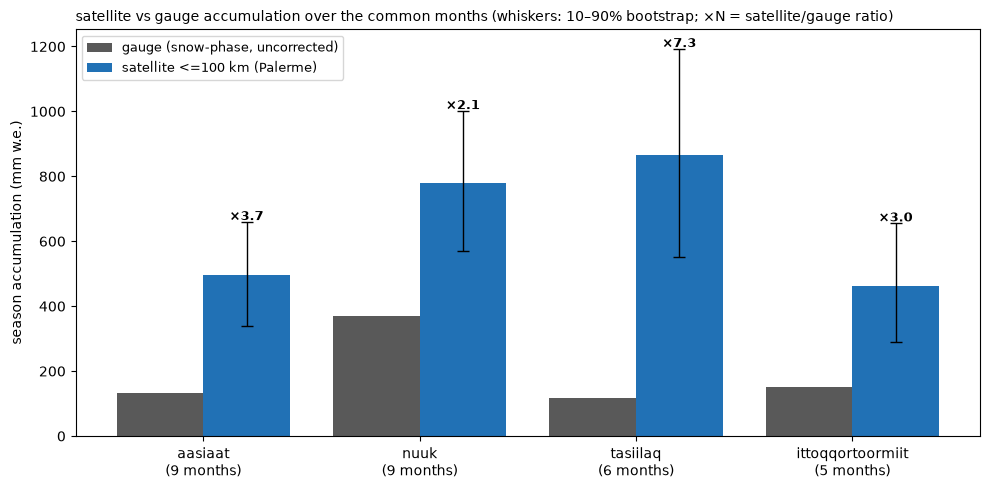

monthly detail (sat vs gauge, mm):
  aasiaat            01:    82/23.9  02:    29/17.1  03:    46/20.5  04:    21/ 4.3  05:    46/13.0  06:    67/ 0.2  10:    72/24.3  11:    45/13.5  12:    91/16.4
  nuuk               01:    74/49.0  02:    59/46.6  03:   172/64.1  04:    68/25.5  05:    58/65.7  06:    33/ 0.7  10:    98/28.3  11:   120/20.9  12:    99/67.8
  tasiilaq           04:   153/13.7  05:   226/22.0  06:   129/ 0.1  10:     3/31.9  11:    82/17.6  12:   247/32.5
  ittoqqortoormiit   05:   155/19.0  06:   127/ 0.4  10:   126/40.1  11:    13/ 3.4  12:    53/89.0


In [11]:
# --- plotting season totals: gauge vs satellite bars with bootstrap whiskers ---
fig, ax = plt.subplots(figsize=(10, 5))
bar_x = np.arange(len(season_table))
ax.bar(bar_x - 0.2, season_table["gauge_mm"], 0.4, color="0.35",
       label="gauge (snow-phase, uncorrected)")
ax.bar(bar_x + 0.2, season_table["sat_mm"], 0.4, color="#2171b5",
       label="satellite <=100 km (Palerme)")
ax.errorbar(bar_x + 0.2, season_table["sat_mm"],
            yerr=[season_table["sat_mm"] - season_table["ci10"],
                  season_table["ci90"] - season_table["sat_mm"]],
            fmt="none", ecolor="k", elinewidth=1, capsize=4)
# satellite/gauge ratio printed above each whisker
for i, row in season_table.iterrows():
    ax.text(i + 0.2, row["ci90"] + 5, f"×{row['ratio']:.1f}", ha="center",
            fontsize=9, fontweight="bold")
ax.set_xticks(bar_x, [f"{site_name}\n({n_months} months)"
                      for site_name, n_months
                      in zip(season_table["site"], season_table["months"])])
ax.set_ylabel("season accumulation (mm w.e.)")
ax.set_title("satellite vs gauge accumulation over the common months "
             "(whiskers: 10–90% bootstrap; ×N = satellite/gauge ratio)",
             loc="left", fontsize=10)
ax.legend(fontsize=9)
fig.savefig("../figures/eo_dmi_accumulation_stations.png", dpi=300,
            bbox_inches="tight")
plt.tight_layout()
plt.show()

# --- monthly detail per site: satellite / gauge mm ---
print("monthly detail (sat vs gauge, mm):")
for site_name, monthly_table in monthly_by_site.items():
    line = "  ".join(f"{row.month[-2:]}: {row.sat_mm:5.0f}/{row.gauge_mm:4.1f}"
                     for row in monthly_table.itertuples())
    print(f"  {site_name:<18} {line}")

## 5 · Takeaways

*(numbers refer to the tables and figures above — regenerate after adding
months)*

- **Detection**: compare each site's POD/FAR and FSS panel against Aasiaat's.
  If all four sit below useful skill, instantaneous detection agreement at
  point gauges is a structural limit of the geometry (blind zone + gauge
  floor + track-vs-point), not an Aasiaat quirk.
- **Accumulation**: the ×N annotations are the test of the ~3× satellite-high
  bias. Consistent ratios across four sites with different climates (west
  coast, east coast, fjord) would make the virga / blind-zone-extrapolation
  explanation hard to escape — and would motivate comparing at a higher
  reference level or against the reflectivity-based C-SNOW-style rates.
- Ittoqqortoormiit contributes only its trustworthy months (May+); Tasiilaq
  starts in March. Nuuk is the strongest replication site: full six months,
  98% gauge, closest approaches under 2 km.
- Next: the miss autopsy (gauge-only events vs cloud-top height in the
  curtains) across all four sites — the blind-zone hypothesis now has four
  times the cases to test against.